In [46]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [47]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path(".")  
FILES = {
    "Total": "CIVPART.csv",
    "Men": "LNS11300001.csv",
    "Women": "LNS11300002.csv",
}

total_raw = pd.read_csv(DATA_DIR / FILES["Total"])
men_raw   = pd.read_csv(DATA_DIR / FILES["Men"])
women_raw = pd.read_csv(DATA_DIR / FILES["Women"])

In [60]:
def standardize_lfpr(df: pd.DataFrame, series_name: str) -> pd.DataFrame:
   
    df = df.copy()

    if "observation_date" in df.columns:
        value_cols = [c for c in df.columns if c != "observation_date"]
        if len(value_cols) != 1:
            raise ValueError(
                f"{series_name}: expected 1 value column besides observation_date, found {value_cols}"
            )
        val_col = value_cols[0]
        out = df.rename(columns={"observation_date": "date", val_col: series_name})
        out["date"] = pd.to_datetime(out["date"])
        out[series_name] = pd.to_numeric(out[series_name], errors="coerce")
        return out[["date", series_name]].sort_values("date").reset_index(drop=True)

total = standardize_lfpr(total_raw, "Total")
men   = standardize_lfpr(men_raw, "Men")
women = standardize_lfpr(women_raw, "Women")

In [56]:
lfpr_monthly = total.merge(men, on="date", how="inner").merge(women, on="date", how="inner")

In [57]:
lfpr_annual = (
    lfpr_monthly.assign(year=lfpr_monthly["date"].dt.year)
    .groupby("year")[["Total", "Men", "Women"]]
    .mean()
    .reset_index()
    .sort_values("year")
    .reset_index(drop=True)
)

In [58]:
lfpr_monthly.to_csv(DATA_DIR / "lfpr_us_monthly_clean.csv", index=False)
lfpr_annual.to_csv(DATA_DIR / "lfpr_us_annual_clean.csv", index=False)

print("Saved:")
print(" -", DATA_DIR / "lfpr_us_monthly_clean.csv")
print(" -", DATA_DIR / "lfpr_us_annual_clean.csv")

Saved:
 - lfpr_us_monthly_clean.csv
 - lfpr_us_annual_clean.csv


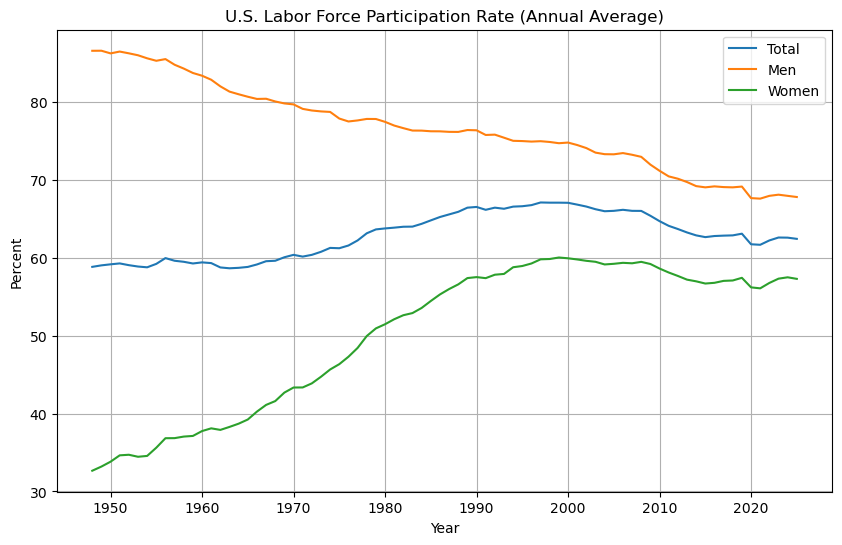

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(lfpr_annual["year"], lfpr_annual["Total"], label="Total")
plt.plot(lfpr_annual["year"], lfpr_annual["Men"], label="Men")
plt.plot(lfpr_annual["year"], lfpr_annual["Women"], label="Women")
plt.title("U.S. Labor Force Participation Rate (Annual Average)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.grid(True)
plt.legend()
plt.show()

In [52]:
assert not lfpr_monthly.empty, "Monthly LFPR dataset is empty after merge"
assert not lfpr_annual.empty, "Annual LFPR dataset is empty after aggregation"

assert lfpr_annual["year"].is_monotonic_increasing, "Years should be increasing"

assert lfpr_annual[["Total", "Men", "Women"]].notna().all().all(), "Missing values in annual LFPR"

bounds_ok = ((lfpr_annual[["Total", "Men", "Women"]] >= 0) &
             (lfpr_annual[["Total", "Men", "Women"]] <= 100)).all().all()
assert bounds_ok, "LFPR values out of bounds [0,100]"

assert lfpr_annual["Men"].mean() > lfpr_annual["Women"].mean(), "Unexpected: men's avg LFPR <= women's avg LFPR"

In [54]:
def lfpr_rate(year: int, sex: str, annual_df: pd.DataFrame = lfpr_annual) -> float:
    """
    Return labor force participation rate (%) for a given year and sex.
    sex must be one of: 'Total', 'Men', 'Women' (case-insensitive).
    """
    if not isinstance(year, int):
        raise TypeError("year must be an int")
    sex_norm = sex.strip().title()
    if sex_norm not in {"Total", "Men", "Women"}:
        raise ValueError("sex must be one of: 'Total', 'Men', 'Women'")

    row = annual_df.loc[annual_df["year"] == year, sex_norm]
    if row.empty:
        raise ValueError(f"Year {year} not found in dataset")
    return float(row.iloc[0])